# Exploration approfondie de la base d'apprentissage

In [26]:
import pandas as pd
import sys
import os
import warnings

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
# Configuration
FILE_PATH = "../data_finale/base_apprentissage.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [28]:
print("Chargement du dataset")

df_base = pd.read_csv(FILE_PATH)

# Taille du dataset
print(f"Taille du dataset : {df_base.shape[0]:,} lignes × {df_base.shape[1]} colonnes")

Chargement du dataset
Taille du dataset : 17,122 lignes × 129 colonnes


In [29]:
print("Types des variables")

analyser_types_et_stats(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 116
Variables catégorielles: 13

Statistiques descriptives (variables numériques)
                              count          mean           std       min           25%           50%           75%           max
season                      17122.0  2.262805e+03  1.684469e+02   2021.00  2.122000e+03  2.223000e+03  2.425000e+03  2.526000e+03
born                        17121.0  1.996656e+03  4.833398e+00   1977.00  1.993000e+03  1.997000e+03  2.000000e+03  2.009000e+03
Playing Time_MP             17122.0  1.940083e+01  1.134931e+01      1.00  9.000000e+00  2.100000e+01  2.900000e+01  3.800000e+01
Playing Time_Starts         17122.0  1.406214e+01  1.122339e+01      0.00  3.000000e+00  1.300000e+01  2.300000e+01  3.800000e+01
Playing Time_Min            17122.0  1.261434e+03  9.606934e+02      1.00  3.600000e+02  1.146000e+03  2.041000e+03  3.420000e+03
Playing Time_90s            17122.0  1.401585e+01  1.067448e+0

In [30]:
# Conversion de l'âge en numérique
df_base["age"] = pd.to_numeric(df_base["age"], errors="coerce")

# Poste simplifié (premier poste mentionné)
df_base["pos_simple"] = df_base["pos"].str.split(",").str[0]

# Saison lisible
season_map = {2021:"2020/21", 2122:"2021/22", 2223:"2022/23",
              2324:"2023/24", 2425:"2024/25", 2526:"2025/26"}
df_base["season_label"] = df_base["season"].map(season_map).fillna(df_base["season"].astype(str))

TARGET_M = TARGET  # en euros ; on divisera par 1e6 pour afficher en millions

Analyse des valeurs manquantes
                       nb_missing     pct
Performance_PKwon           17122  100.00
Performance_PKcon           17122  100.00
Penalty Kicks_Save%         16231   94.80
Performance_CS%             15918   92.97
Performance_Save%           15887   92.79
Penalty Kicks_PKatt         15863   92.65
Performance_L               15863   92.65
Performance_SoTA            15863   92.65
Performance_GA              15863   92.65
Performance_GA90            15863   92.65
Performance_W               15863   92.65
Performance_CS              15863   92.65
Penalty Kicks_PKsv          15863   92.65
Performance_Saves           15863   92.65
Penalty Kicks_PKm           15863   92.65
Penalty Kicks_PKA           15863   92.65
Performance_D               15863   92.65
xg_buildup                   8433   49.25
xg                           8433   49.25
np_xg                        8433   49.25
xa                           8433   49.25
xg_chain                     8433   49.25
Sta

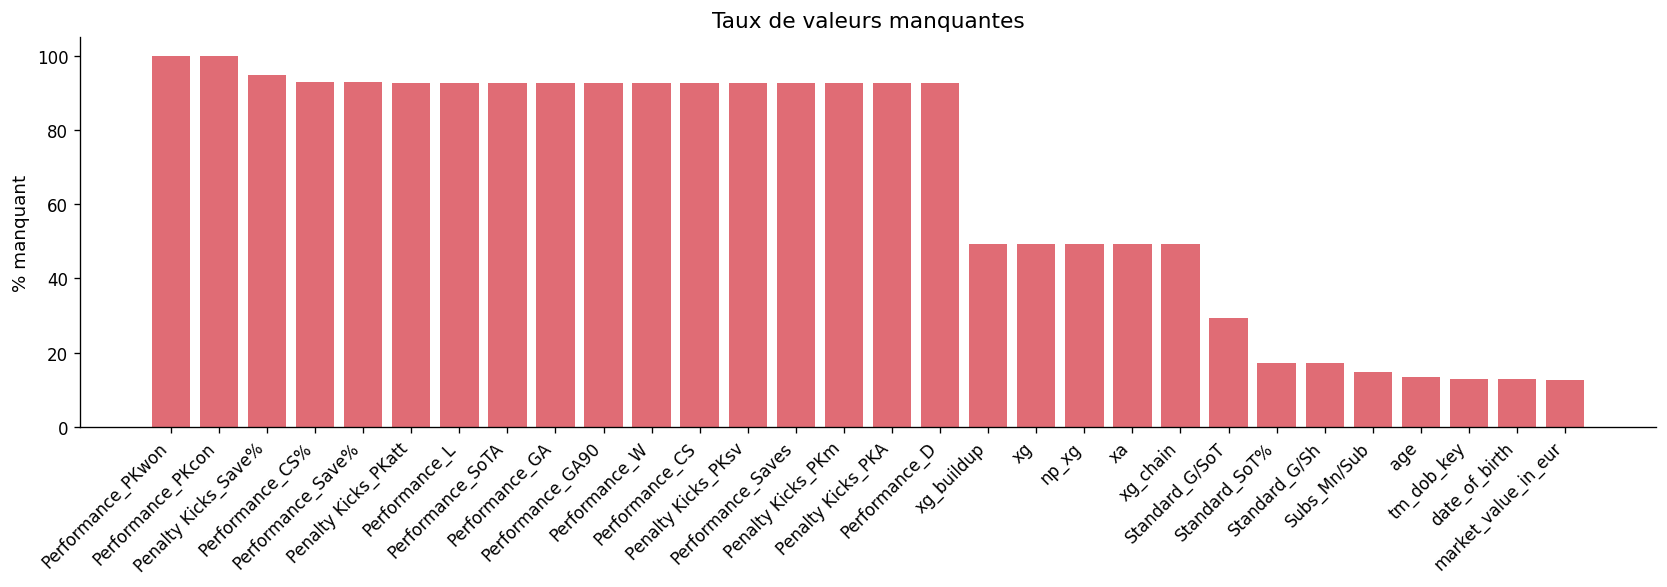

In [31]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

In [32]:
analyser_doublons(df_base)

Analyse des doublons
Lignes dupliquées (toutes colonnes) : 0
Doublons sur (player_id, season) : 3090


Analyse de la variable cible : market_value_in_eur ===
count         14,932
mean      12,053,886
std       17,101,340
min           50,000
25%        2,200,000
50%        6,000,000
75%       15,000,000
max      200,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.54
Kurtosis : 19.68

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


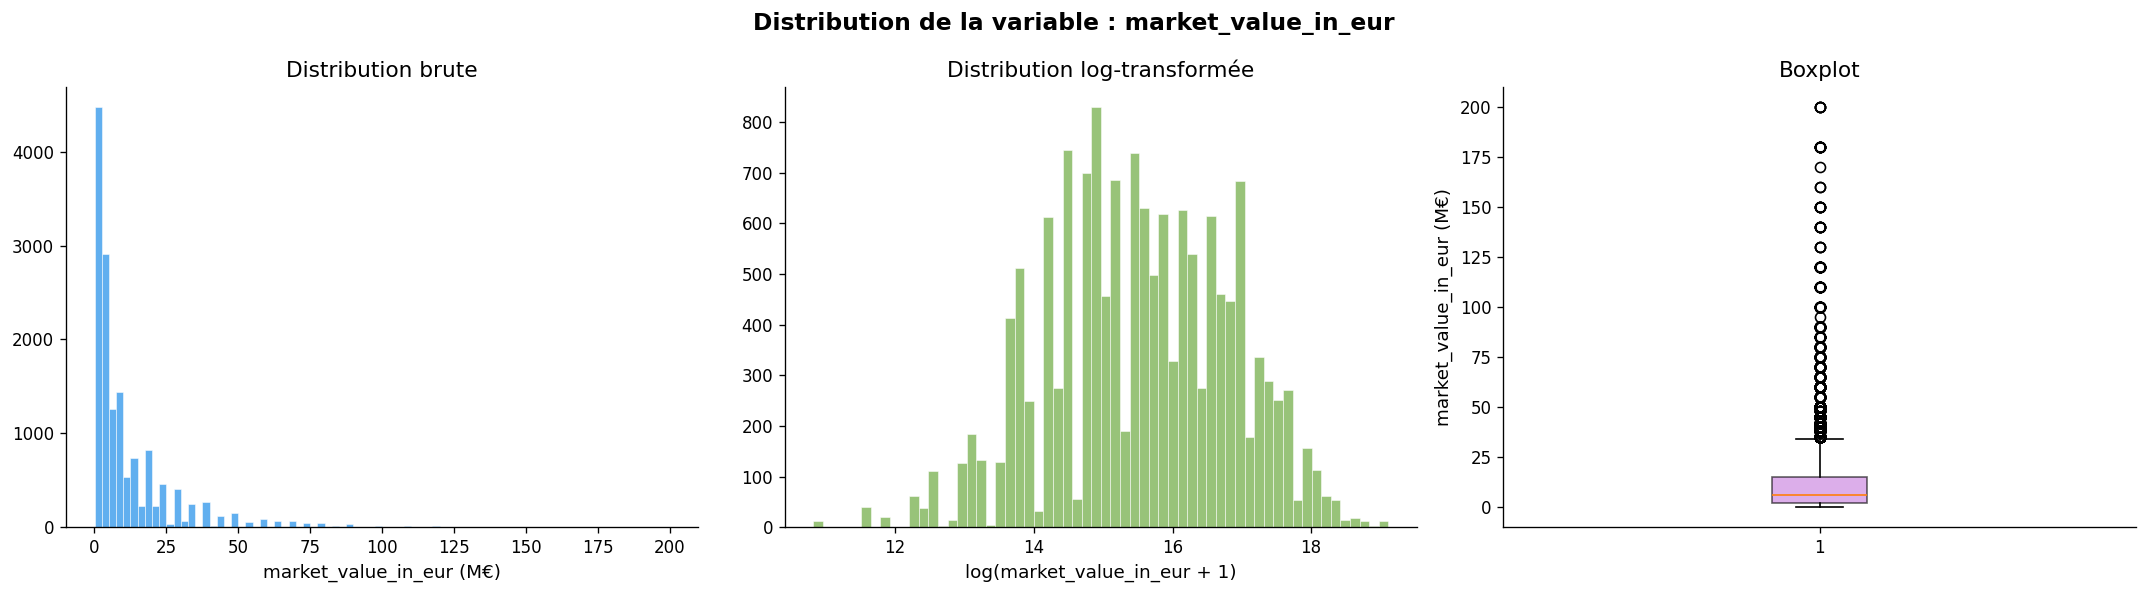

In [33]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


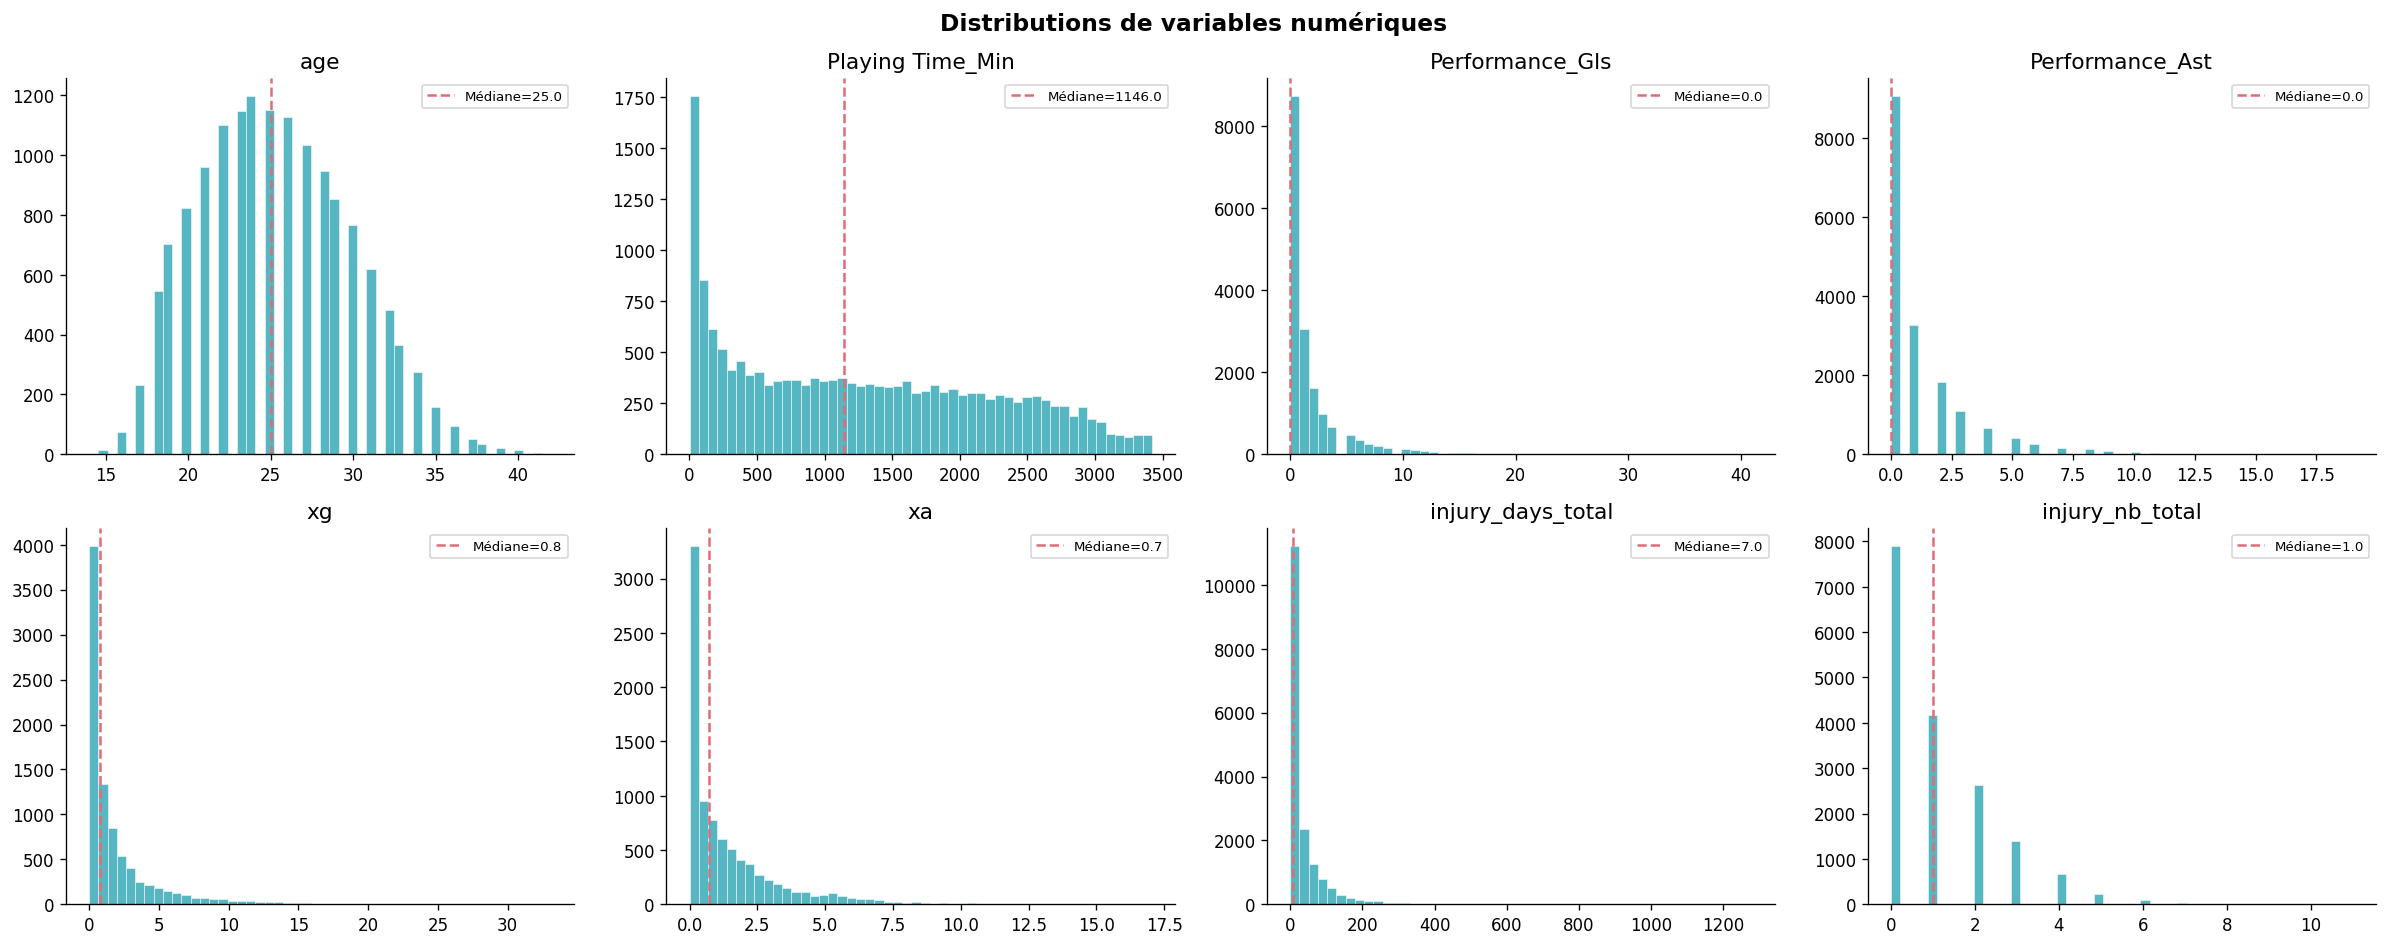

In [34]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

pos (10 modalités) :
pos
MF       5266
DF       4336
FW       2194
MF,FW    1298
GK       1258
FW,MF    1086
DF,MF     987
MF,DF     676
DF,FW      19
FW,DF       2

league (5 modalités) :
league
ESP-La Liga           3689
ITA-Serie A           3664
ENG-Premier League    3461
FRA-Ligue 1           3347
GER-Bundesliga        2961

season (6 modalités) :
season
2122    3033
2223    2991
2021    2956
2425    2921
2324    2906
2526    2315

players_top_nations.png sauvegardé


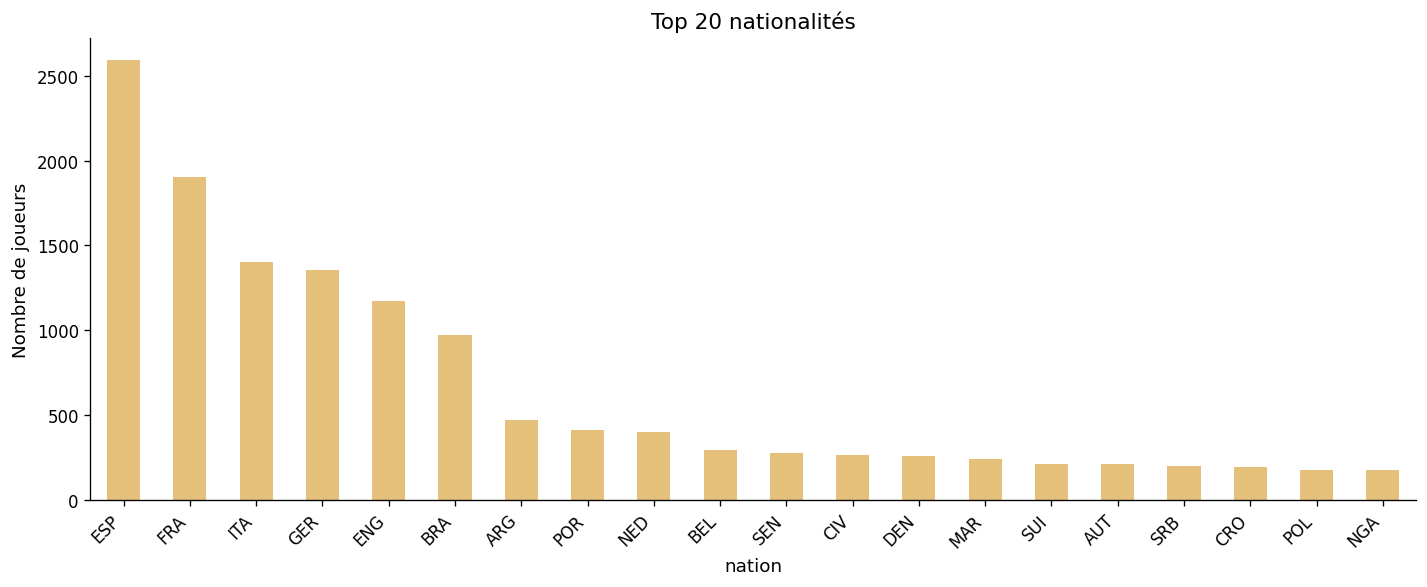

pos.png sauvegardé


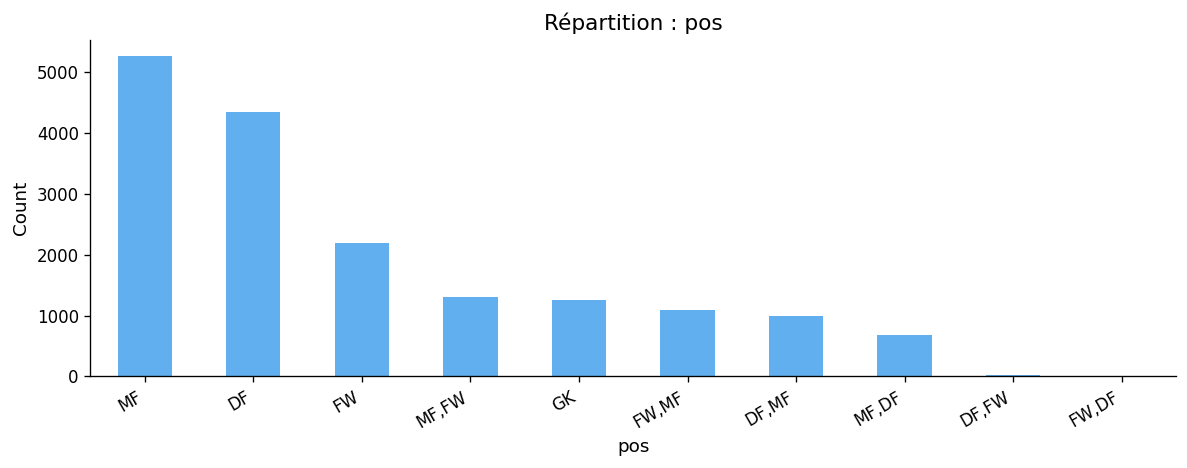

league.png sauvegardé


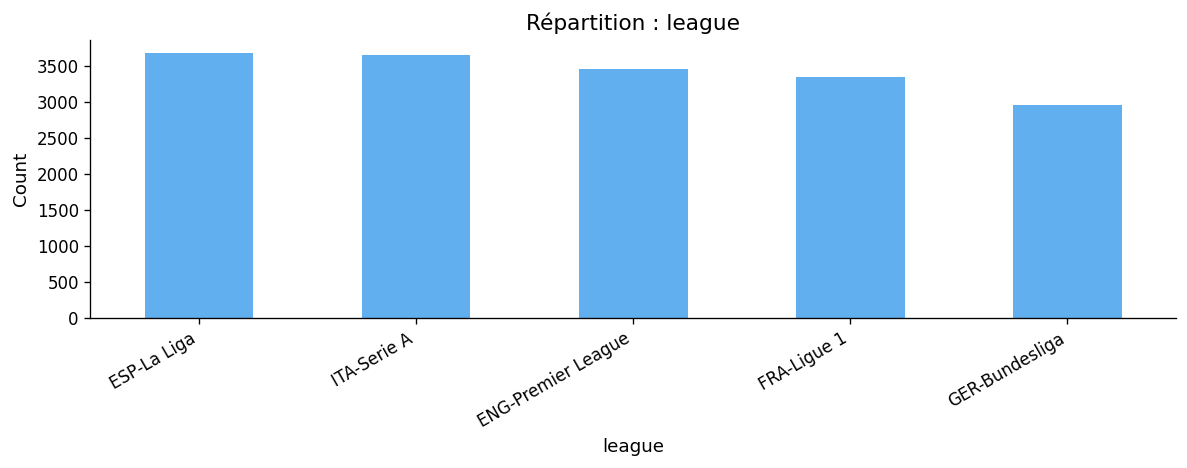

vm_par_pos.png sauvegardé


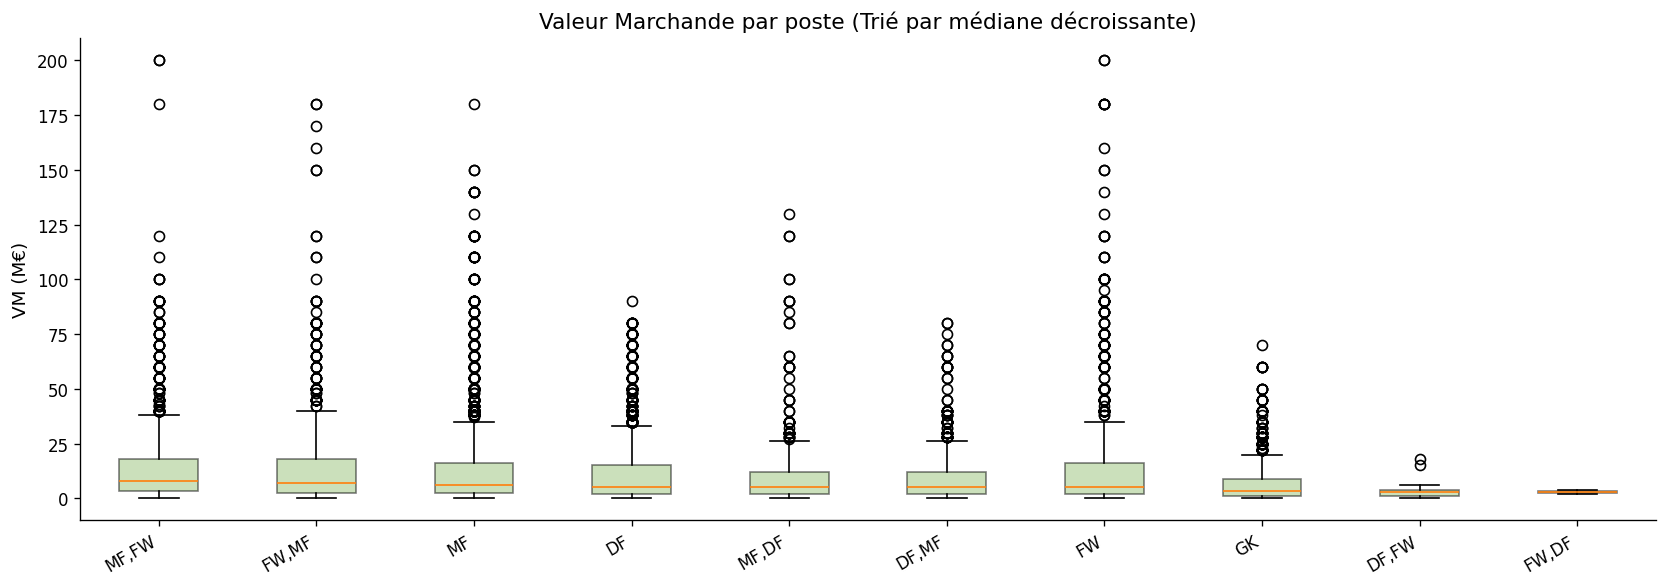

vm_par_league.png sauvegardé


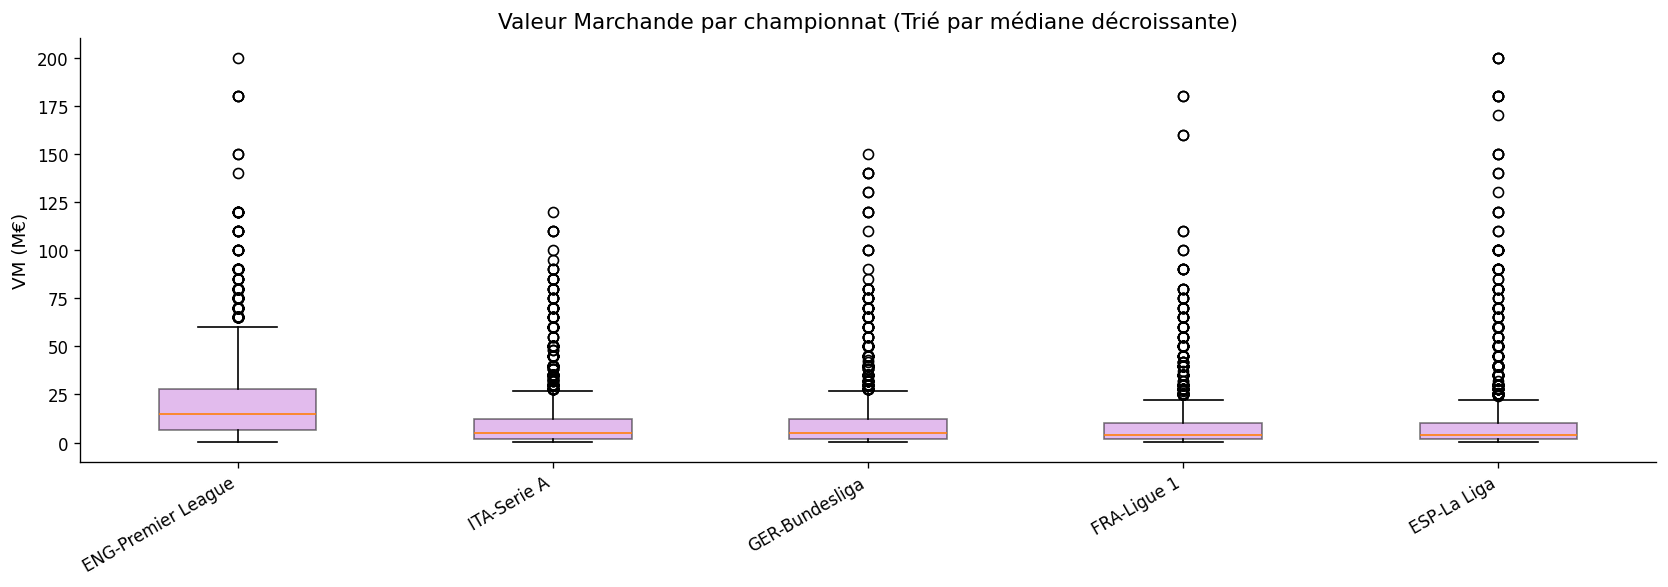

In [35]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [36]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age            19      0.1               19  14806
 Playing Time_Min             0      0.0                0  17122
  Performance_Gls          1581      9.2              374  17122
  Performance_Ast           768      4.5              339  17122
               xg           807      9.3              206   8689
               xa           592      6.8              168   8689
injury_days_total          1442      8.4              382  17122
  injury_nb_total           121      0.7              121  17122


Analyse des relations avec la variable cible : market_value_in_eur

Graphique sauvegardé sous : ..\outputs\eda\relations_market_value_in_eur.png


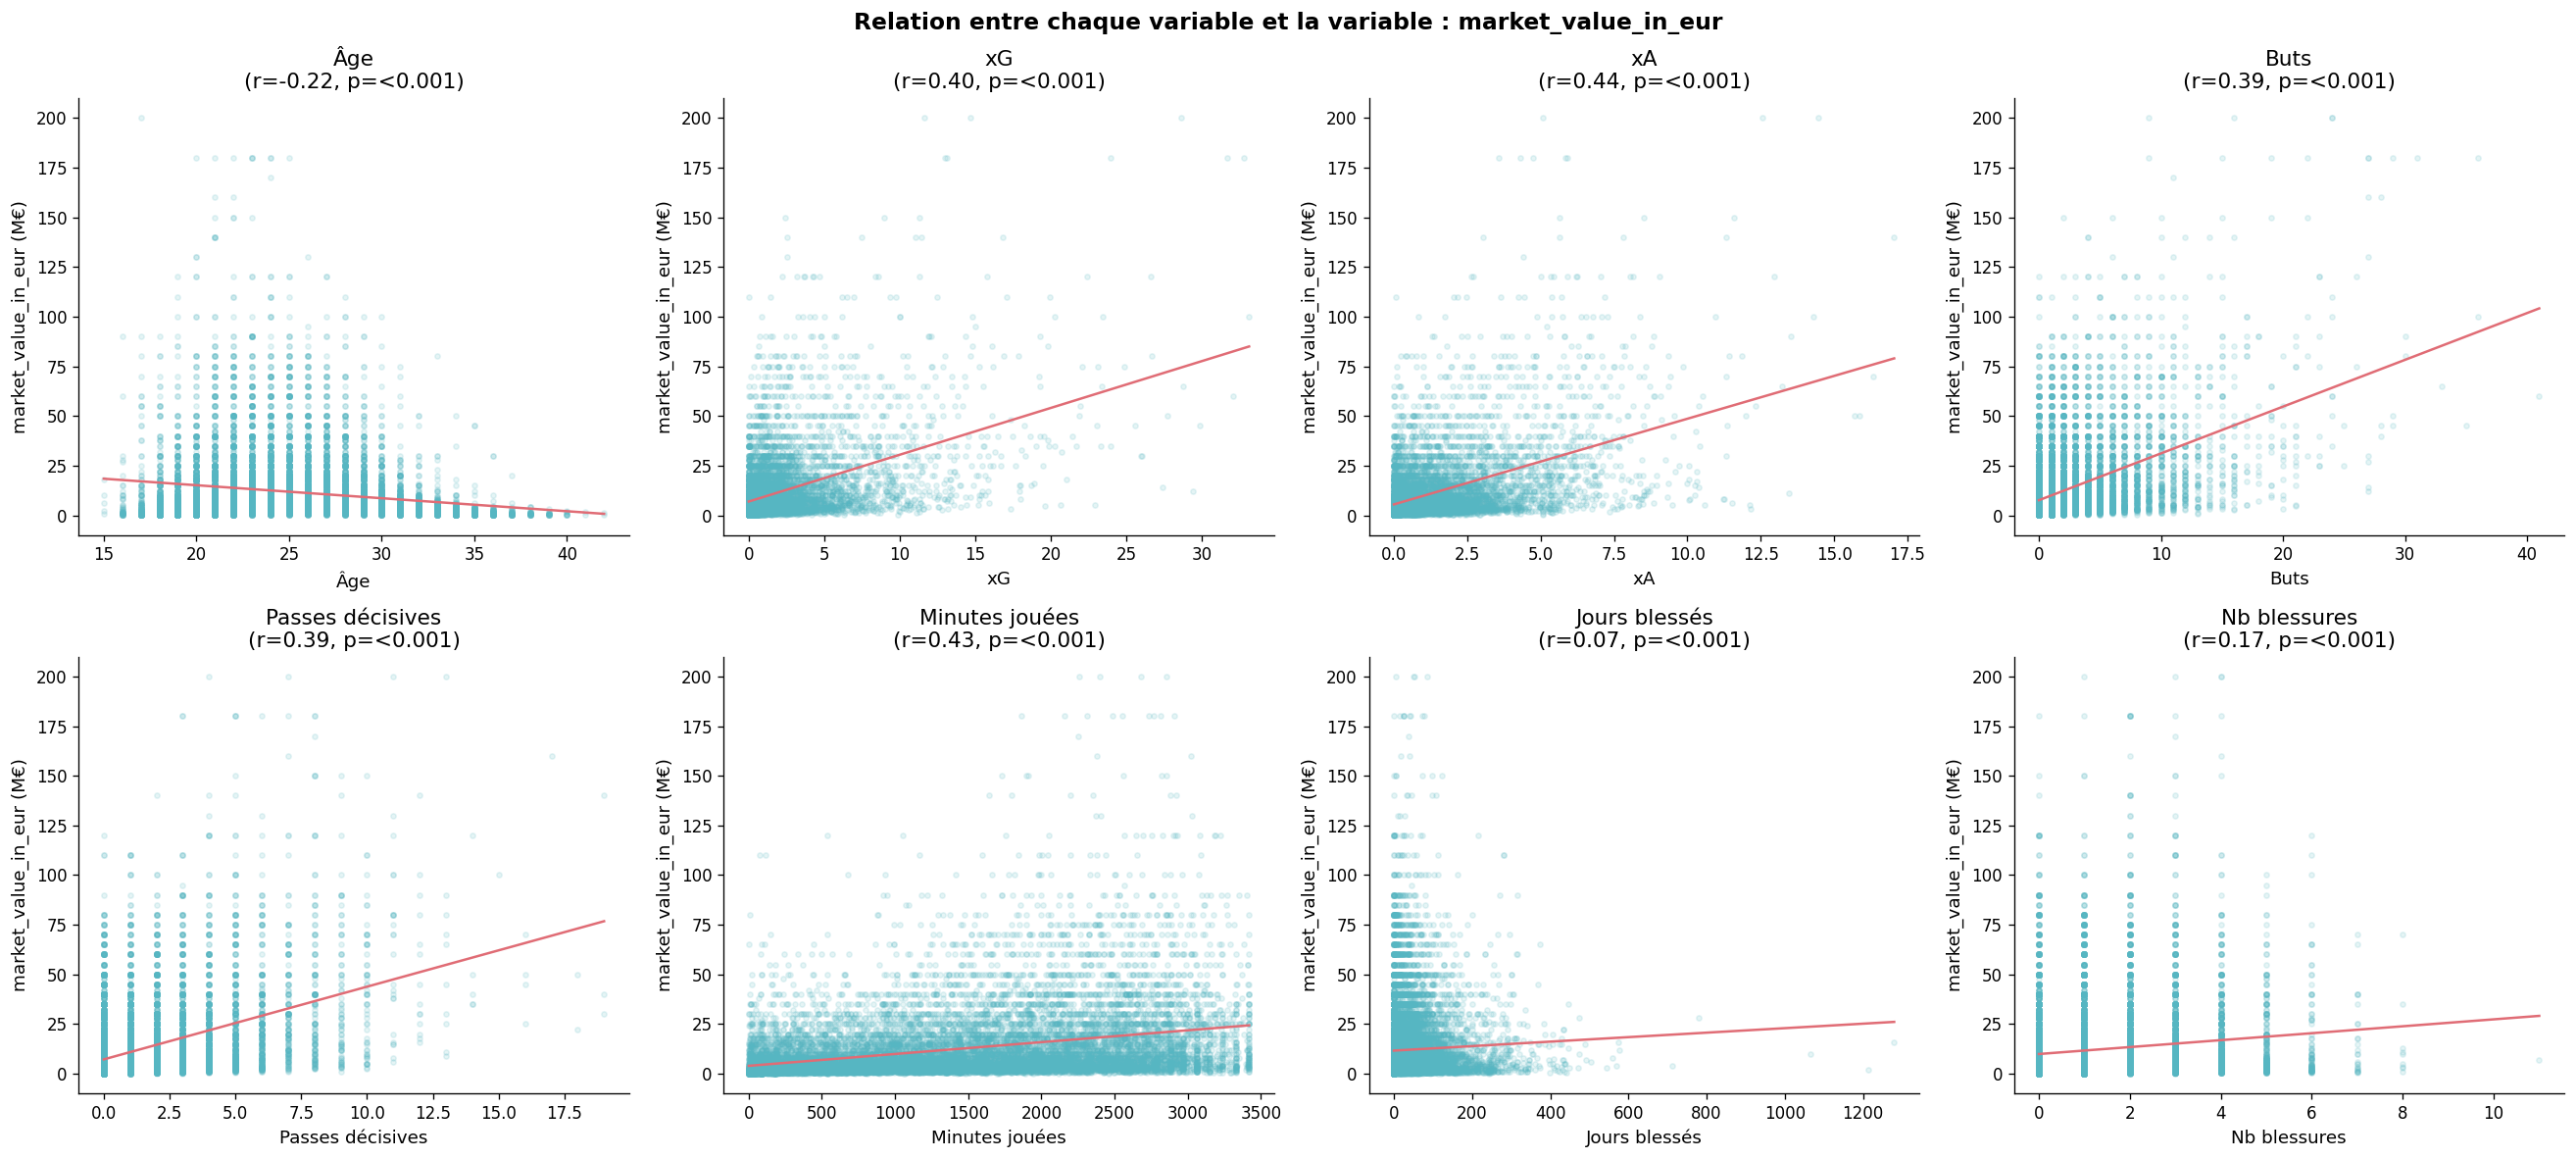

In [37]:
analyser_relations_cible(df_base, TARGET, variables_regresseurs=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
xa                              0.471131
Performance_Gls                 0.453717
xg                              0.448200
Performance_Ast                 0.430721
Playing Time_Min                0.327885
injury_nb_total                 0.136287
injury_days_total               0.040391
age                            -0.175952

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


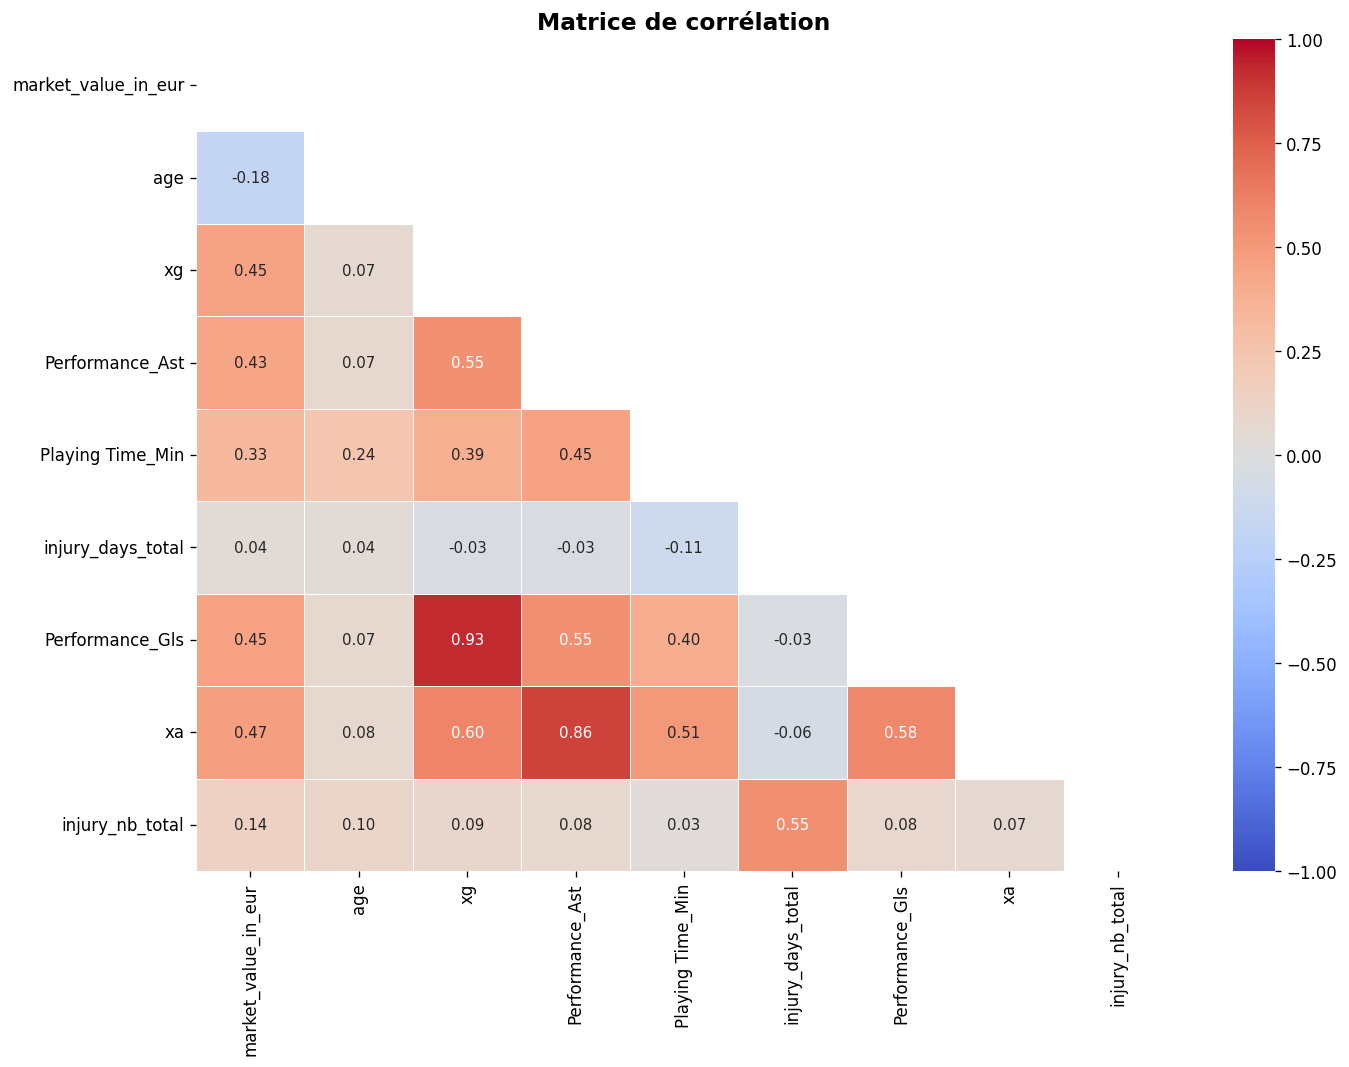


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
Performance_W          0.624231
xg_chain               0.618251
Performance_CS         0.567894
Team Success_onG       0.516945
xg_buildup             0.513561
Performance_G+A        0.503421
Team Success_+/-       0.503157
xa                     0.471131
Standard_Sh            0.470121
Standard_SoT           0.466856
np_xg                  0.460754
Performance_G-PK       0.459572
Performance_Gls        0.453717
Standard_Gls           0.453717
xg                     0.448200
Performance_Ast        0.430721
Team Success_PPM       0.355746
Performance_Saves      0.342130
Playing Time_Starts    0.328627
Starts_Starts          0.328627


In [38]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


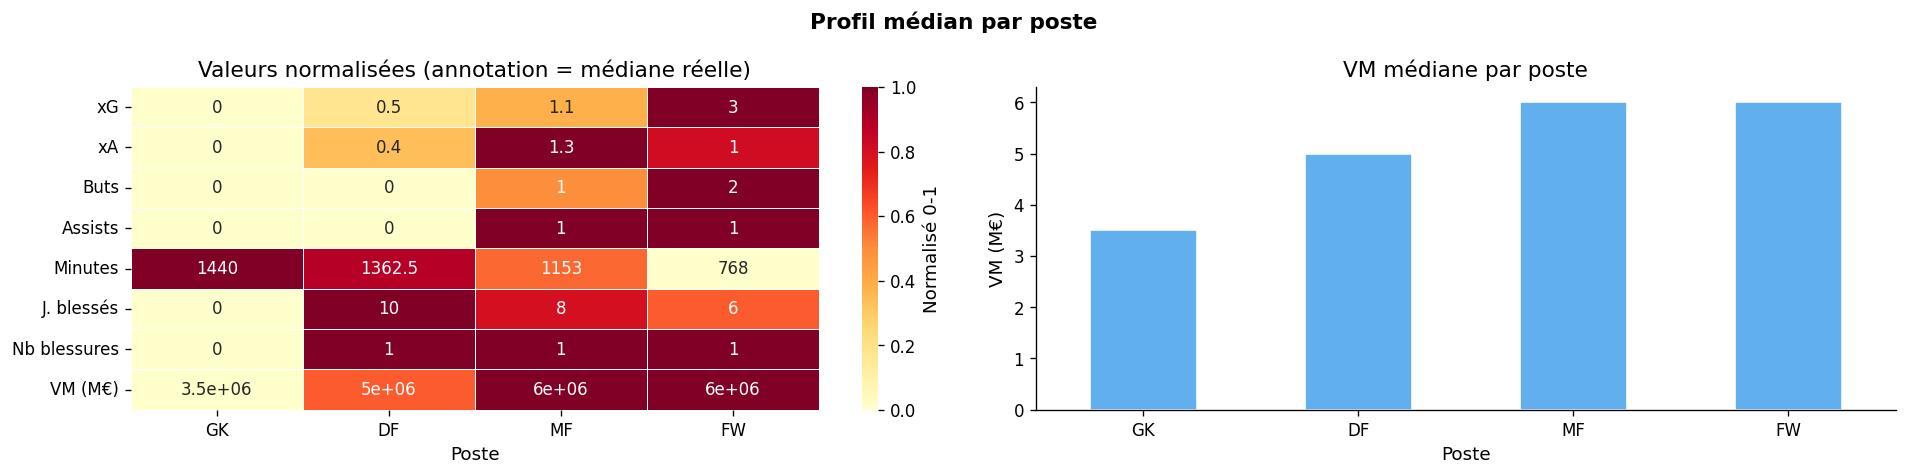

In [39]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des corrélations spécifiques par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_corr_poste.png


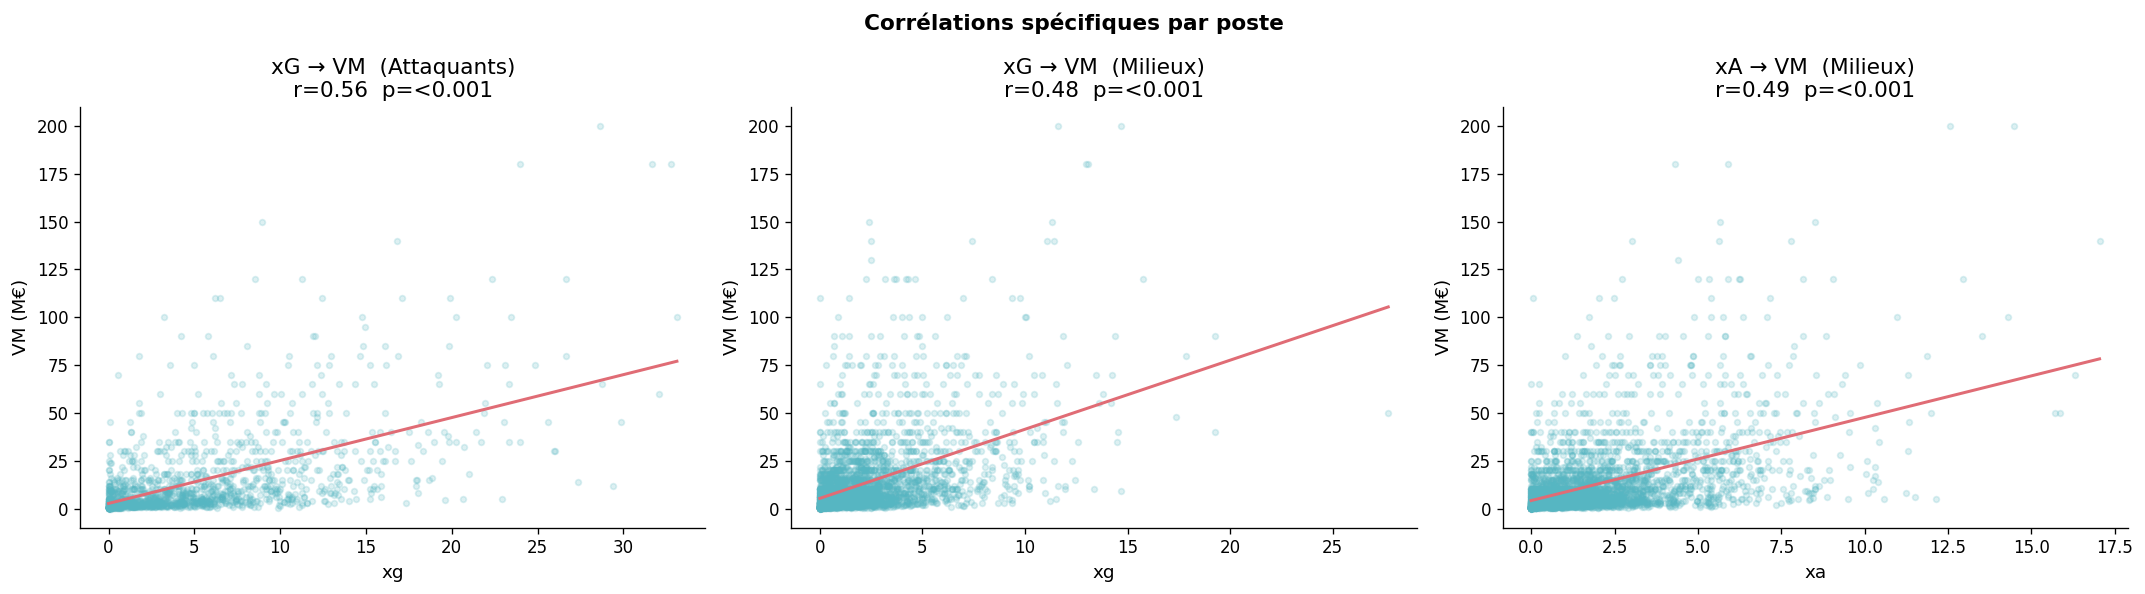

In [40]:
analyser_correlations_specifiques_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


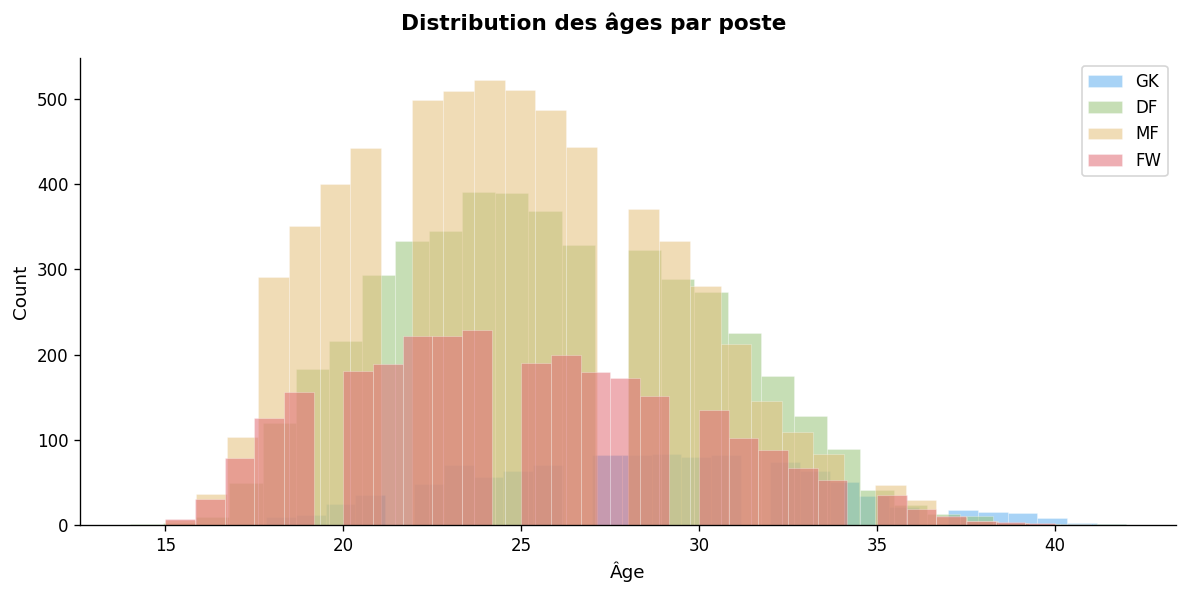


Âge médian par poste
pos_simple
GK    28.0
DF    25.0
MF    24.0
FW    24.0


In [41]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Feature engineering exploratoire

Graphique sauvegardé sous : ..\outputs\eda\feature_engineering.png


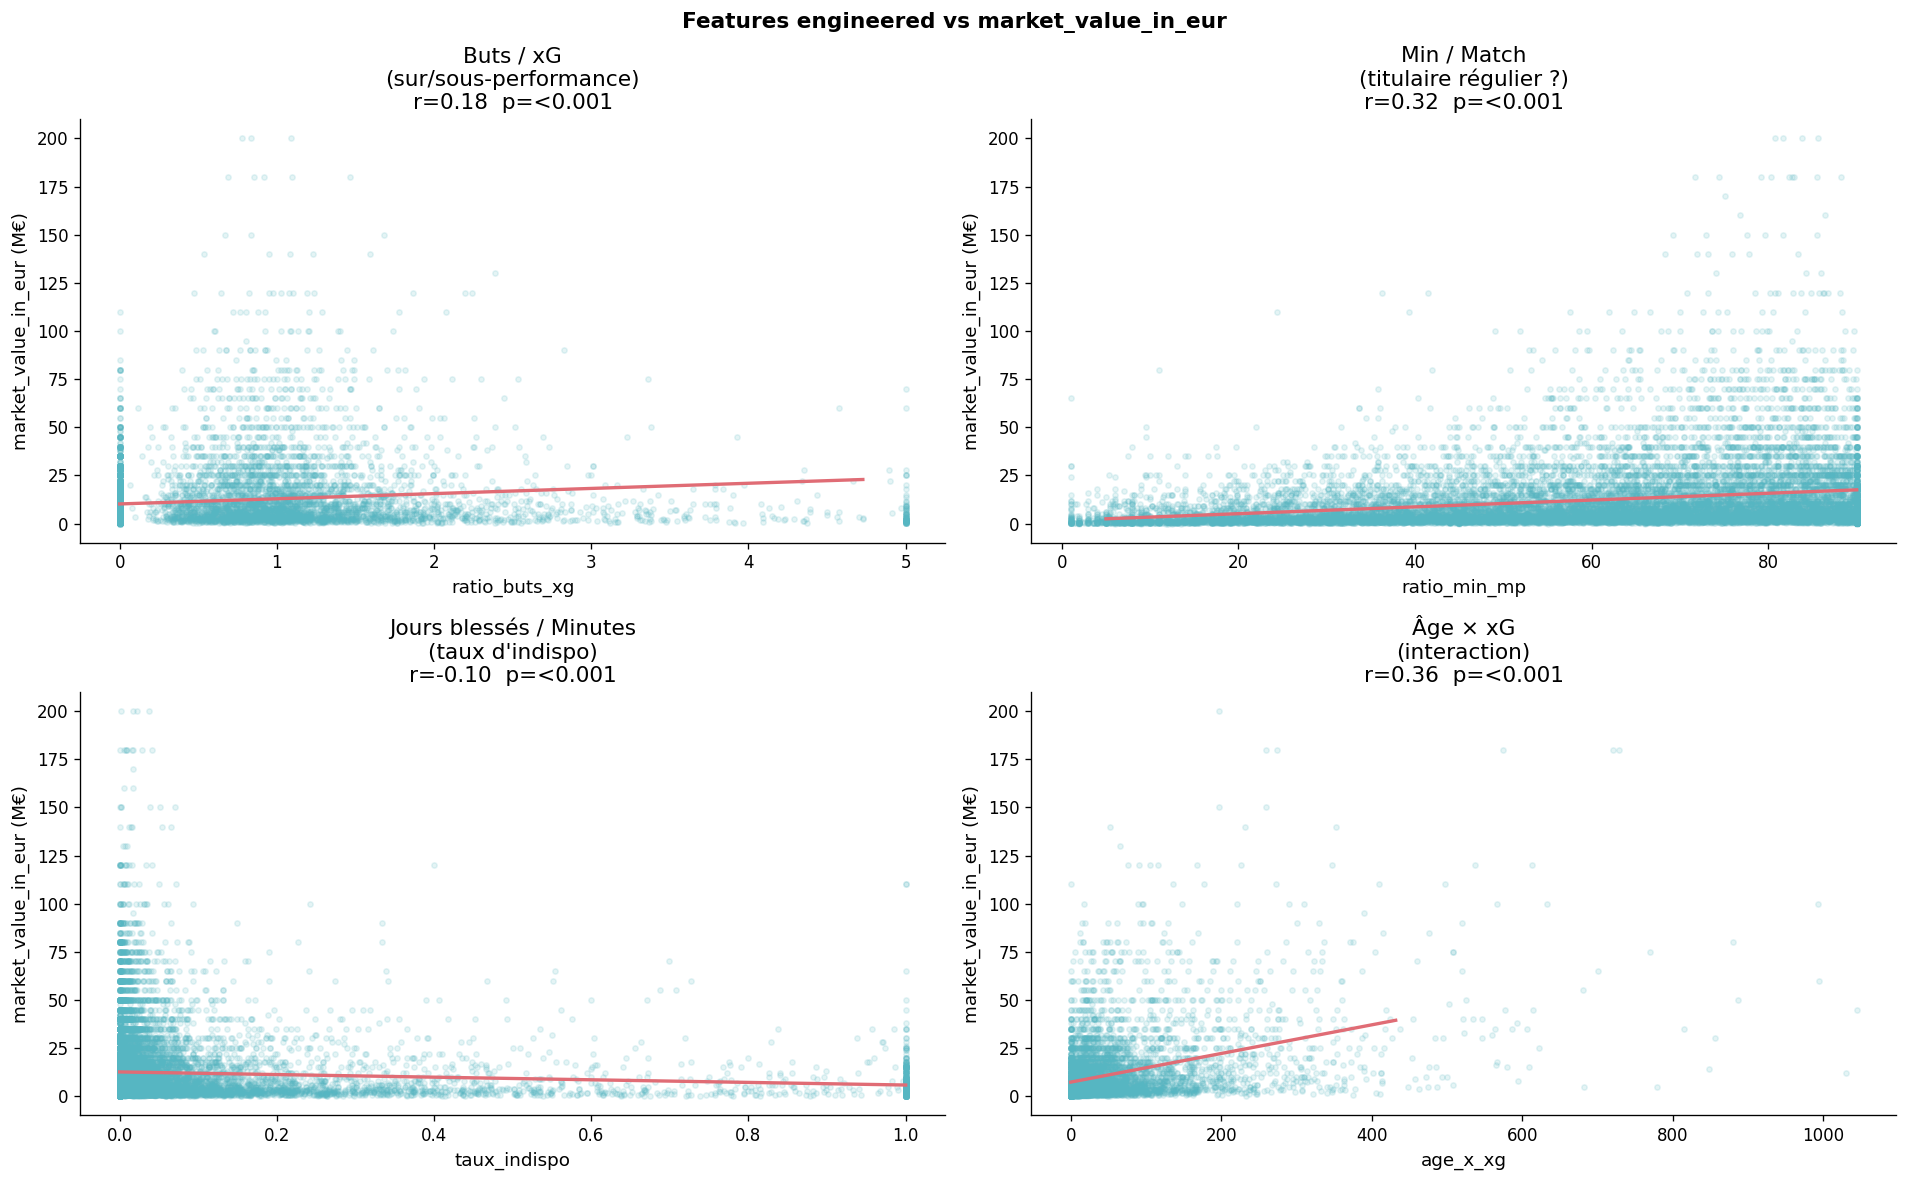


Corrélations (Pearson sur log market_value_in_eur) — features engineered :
  ratio_buts_xg        r=+0.183  p=<0.001
  ratio_min_mp         r=+0.319  p=<0.001
  taux_indispo         r=-0.103  p=<0.001
  age_x_xg             r=+0.364  p=<0.001


In [42]:
analyser_feature_engineering(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse croisée : VM médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


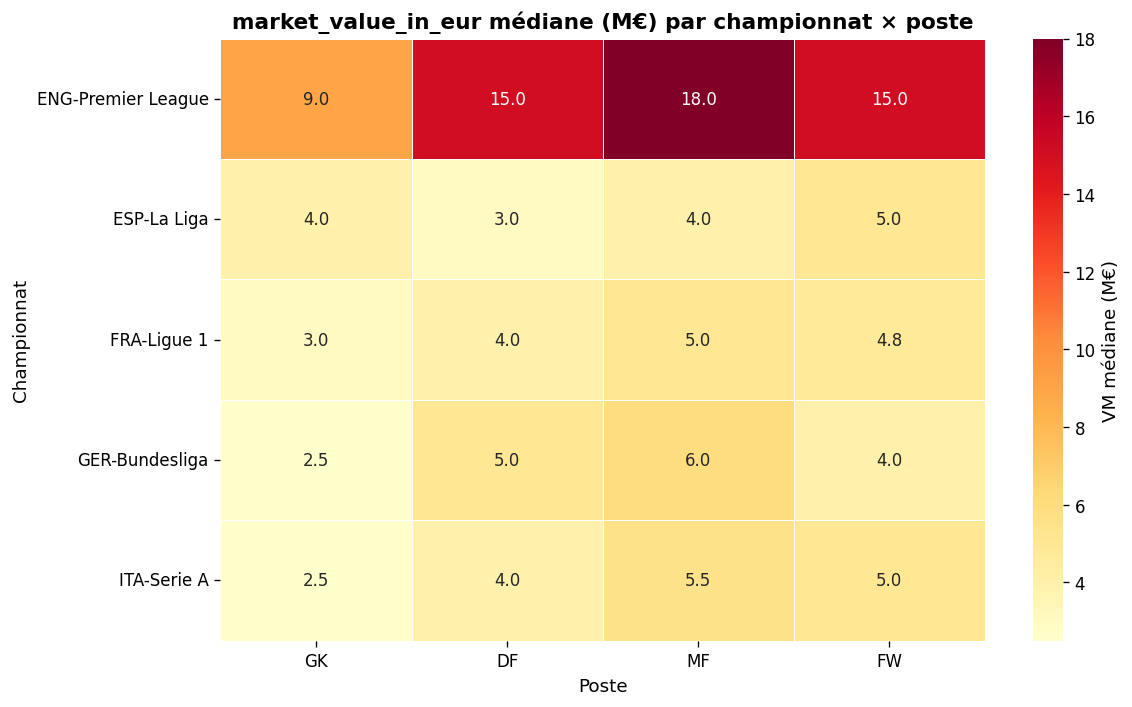

In [43]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat

Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


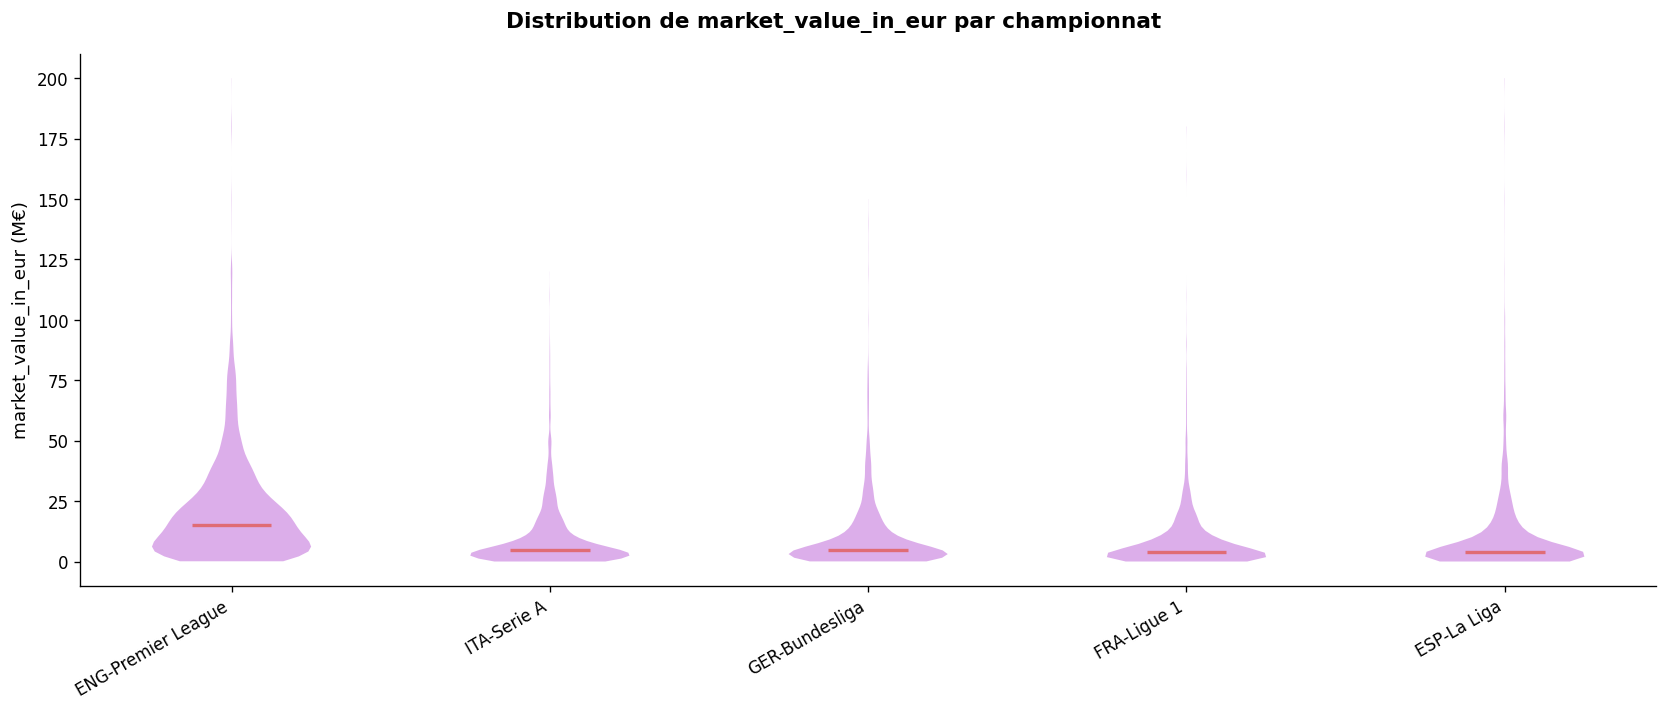

In [44]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 81 observations

Top 20 des joueurs les plus chers
         player pos_simple             league season_label  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
 Erling Haaland         FW ENG-Premier League      2025/26  NaN                200.0 28.638352               24                4.0
   Lamine Yamal         MF        ESP-La Liga      2025/26  NaN                200.0 14.664690               16               84.0
  Kylian Mbappé         FW        ESP-La Liga      2025/26  NaN                200.0       NaN               24               52.0
   Lamine Yamal         MF        ESP-La Liga      2024/25 17.0                200.0 11.593034                9               50.0
Jude Bellingham         MF        ESP-La Liga      2023/24 20.0                180.0 12.974516               19               40.0
 Erling Haaland         FW ENG-Premier League

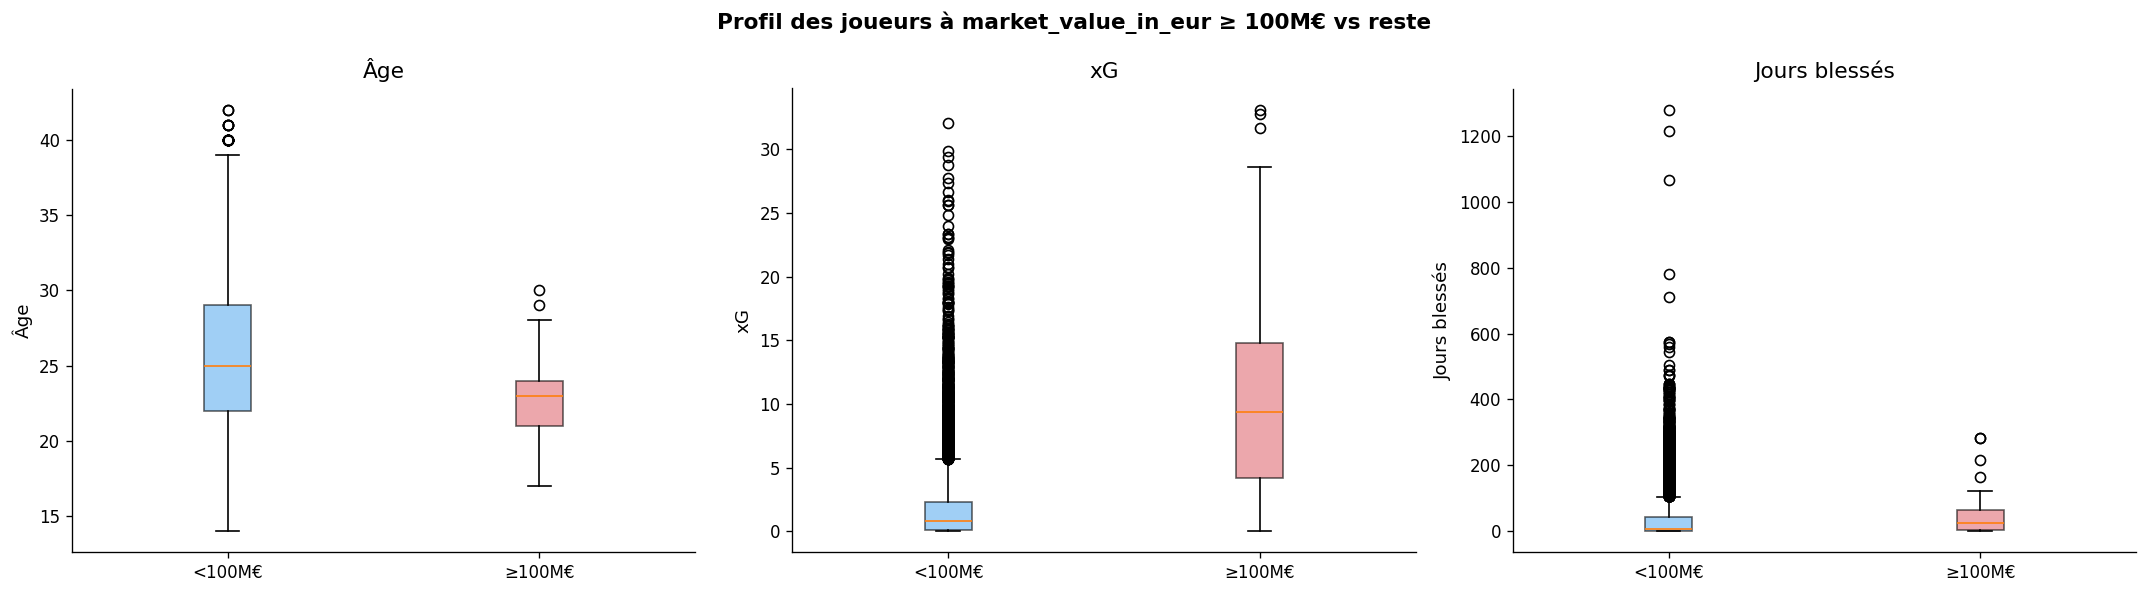

In [45]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des résidus de régression (xG → log(market_value_in_eur)) ===

Régression xG → log(market_value_in_eur)  |  R²=0.169
  Sur-évalués  (résidu > +2.5σ) : 5
  Sous-évalués (résidu < -2.5σ) : 55

Graphique sauvegardé sous : ..\outputs\eda\outliers_residus.png


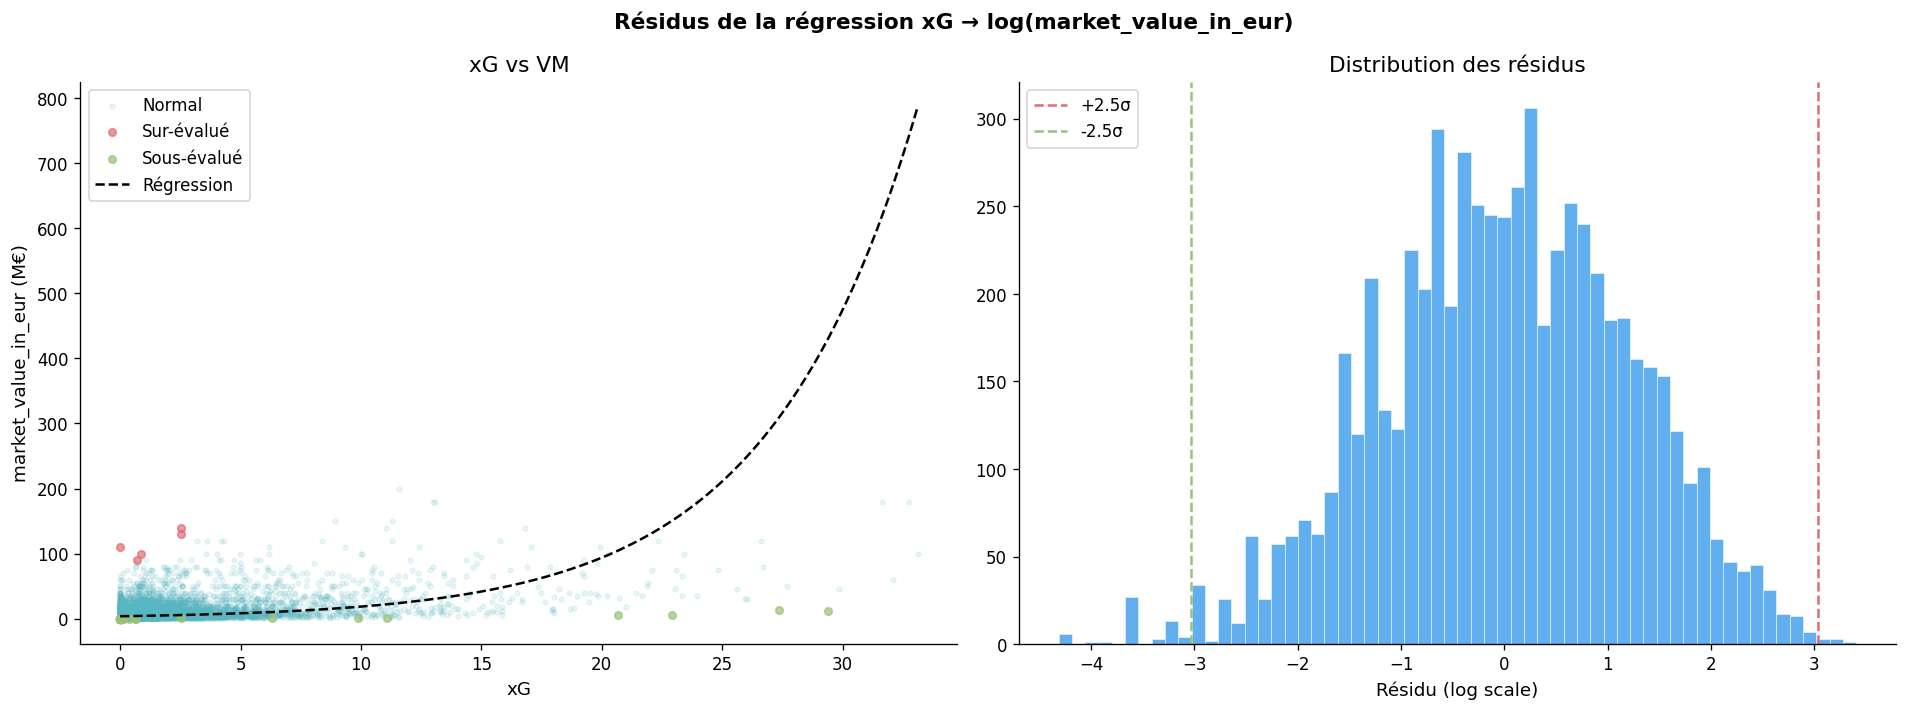

In [46]:
df_res = analyser_residus_regression(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [47]:
afficher_top_anomalies_valeur(df_res, TARGET)

Top joueurs atypiques (Régression vs market_value_in_eur) ===

Top 10 joueurs les plus SUR-évalués vs xG :
           player pos_simple             league  age       xg  market_value_in_eur  residual
            Rodri         MF ENG-Premier League 28.0 0.000000                110.0  3.404025
            Pedri         MF        ESP-La Liga 21.0 2.510431                140.0  3.238026
Eduardo Camavinga         MF        ESP-La Liga 20.0 0.875550                100.0  3.166711
Federico Valverde         MF        ESP-La Liga 26.0 2.511641                130.0  3.163722
   Moisés Caicedo         MF ENG-Premier League 22.0 0.691102                 90.0  3.091266

Top 10 joueurs les plus SOUS-évalués vs xG :
            player pos_simple      league  age       xg  market_value_in_eur  residual
     Niama Sissoko         FW FRA-Ligue 1 18.0 0.138512                  0.0 -4.314633
  Sofiane Sidi Ali         FW FRA-Ligue 1 28.0 0.068025                  0.0 -4.303201
     Prosper Peter         F

In [48]:
verifier_coherence_age_naissance(df_base)

Contrôle de qualité et cohérence des données

Cohérence born/age/season (14806/17122 lignes analysables) :
  Différence nulle (exacte)      : 9,801
  Différence ≤ 1 an              : 14,806
  Différence > 1 an (anomalie)   : 0
  Différence > 5 ans             : 0


In [49]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (17122/17122 lignes analysées) :
  Cohérents (diff = 0)           : 16,443
  Diff ≤ 1 jour                  : 16,443
  Diff > 1 jour (anomalie)       : 679
  Diff max                       : 1214 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur) ===

Évolution VM par saison :
              Médiane (M€)  Moyenne (M€)  Nb joueurs
season_label                                        
2020/21                5.0     10.460627        2649
2021/22                5.0     10.754859        2562
2022/23                5.0     11.359906        2665
2023/24                5.5     12.141676        2571
2024/25                6.0     13.170258        2420
2025/26                8.0     15.187433        2065

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


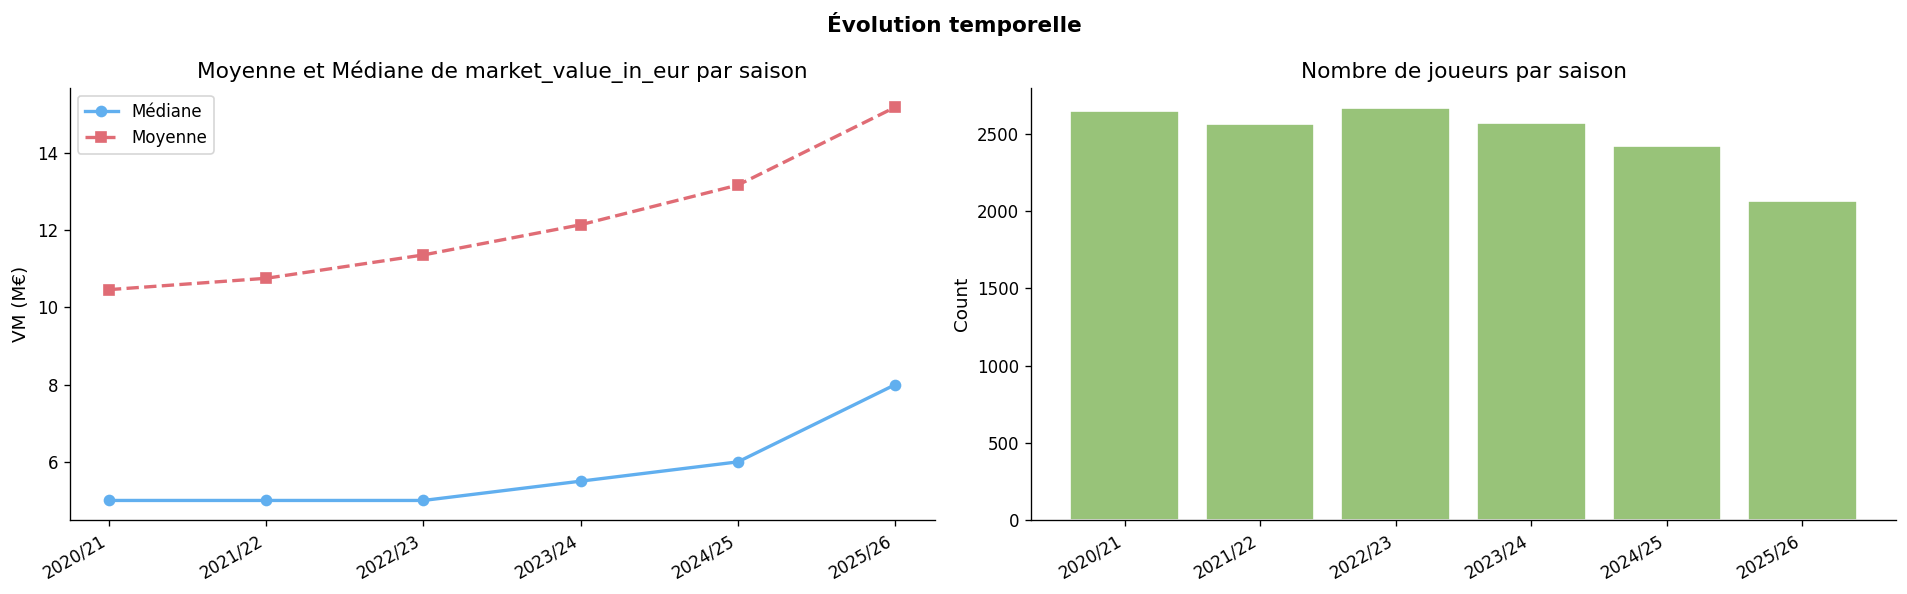

,Médiane (M€),Moyenne (M€),Nb joueurs
season_label,,,
2020/21,5.0,10.460627,2649
2021/22,5.0,10.754859,2562
2022/23,5.0,11.359906,2665
2023/24,5.5,12.141676,2571
2024/25,6.0,13.170258,2420
2025/26,8.0,15.187433,2065


In [50]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)